In [3]:
import numpy as np
import matplotlib.pyplot as plt

import limpy.lcp as ll

OSError: dlopen(/Users/anirbanroy/.local/lib/python2.7/site-packages/camb/camblib.so, 6): Library not loaded: /usr/local/opt/gcc/lib/gcc/9/libgfortran.5.dylib
  Referenced from: /Users/anirbanroy/.local/lib/python2.7/site-packages/camb/camblib.so
  Reason: image not found

In [2]:
# Plot SFR with halomass in redshift range 0 to 8. 
# You can files using "read_sfr" function. or you can use inbuild "plot_sfr_mhalo" directly
# you may need to change the plotting parameters such as xlim, ylim, color etc....

In [3]:
log_mhalo=11  # halo mass in log scale, units are in M_sun
sfr=ll.mhalo_to_sfr(log_mhalo)

/opt/anaconda2/lib/python2.7/site-packages/matplotlib/axes/_base.py:3477: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


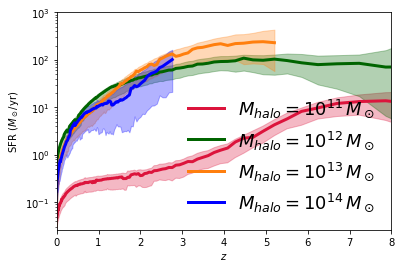

In [4]:
#plot
log_mhalo=[11,12,13,14]
ll.plot_sfr_mhalo(log_mhalo)

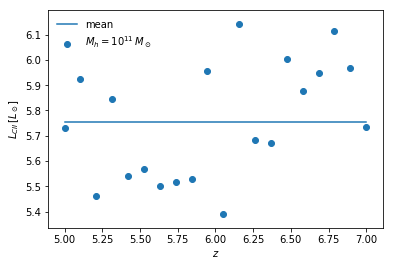

In [5]:
# plot luminosity of CII line at z=6 for the halo mass 1e11. 
# PLEASE NOTE that the result will change if you run the 
#same code again as we have used the scattered relation between SFR and CII luminosity
z=np.linspace(5,7,num=20)
#z=np.array(z)
mh=[11]
lc2=np.zeros(len(z))
for i in range(len(z)):
    lc2[i]=ll.mhalo_to_lcp(z[i],mh, use_scatter=True)

plt.scatter(z,lc2,label=r"$M_{h}=10^{11}\, M_\odot$")
plt.plot(z, np.mean(lc2)*np.ones(len(z)),label="mean")

plt.xlabel("$z$")
plt.ylabel(r"$L_{CII}\,[L_\odot]$")
plt.legend(loc=0,frameon=False)

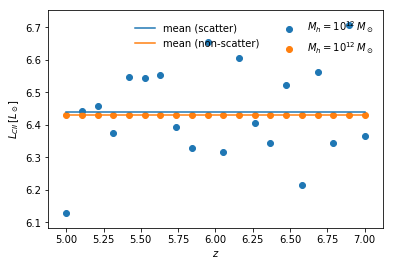

In [6]:
#Compare luminosity of CII line at z=6 for the halo mass 1e12 using LCII-SFR scatter and non-scatter relation. 
mh=[15]
z=np.linspace(5,7,num=20)
lc2_scatter=np.zeros(len(z))
lc2_nonscatter=np.zeros(len(z))

for i in range(len(z)):
    lc2_scatter[i]=ll.mhalo_to_lcp(z[i],mh, use_scatter=True)
    lc2_nonscatter[i]=ll.mhalo_to_lcp(z[i],mh, use_scatter=False)

plt.scatter(z,lc2_scatter,label=r"$M_{h}=10^{12}\, M_\odot$")
plt.plot(z, np.mean(lc2_scatter)*np.ones(len(z)),label="mean (scatter)")


plt.scatter(z,lc2_nonscatter,label=r"$M_{h}=10^{12}\, M_\odot$")
plt.plot(z, np.mean(lc2_nonscatter)*np.ones(len(z)),label="mean (non-scatter)")
plt.legend(loc=0)
plt.xlabel(r"$z$")
plt.ylabel(r"$L_{CII}\,[L_\odot]$")
plt.legend(loc=1,ncol=2,frameon=False)
#plt.ylim(6.0,8)

Text(0,0.5,'$\\log(L_{CII})\\,\\,[L_\\odot]$')

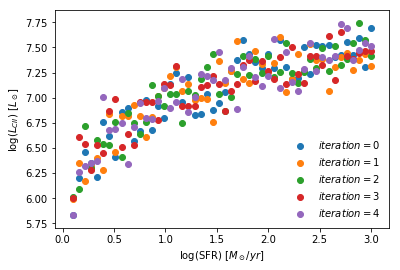

In [7]:
# Make same plot for 5 times at z=6, for different star formation rate to check the Gaussian scatter in L_{CII}
z=7 #redshift
sfr=np.linspace(0.1,3,num=50) #SFR rate
num_of_iteration=5

for i in range(num_of_iteration):
    lc2=ll.sfr_to_lcp_scatter(z, sfr)
    
    #scatter lc2 points
    plt.scatter(sfr,lc2,label=r"$iteration=%d$" %(i))
    plt.legend(loc=0,frameon=False)
    
plt.xlabel(r"$\log(\mathrm{SFR})\,\,[M_\odot/yr]$")
plt.ylabel(r"$\log(L_{CII})\,\,[L_\odot]$")
#plt.ylim(4.0,9)



('Minimum halo mass:', 336666900.0)
('Maximum halo mass:', 321717300000.0)


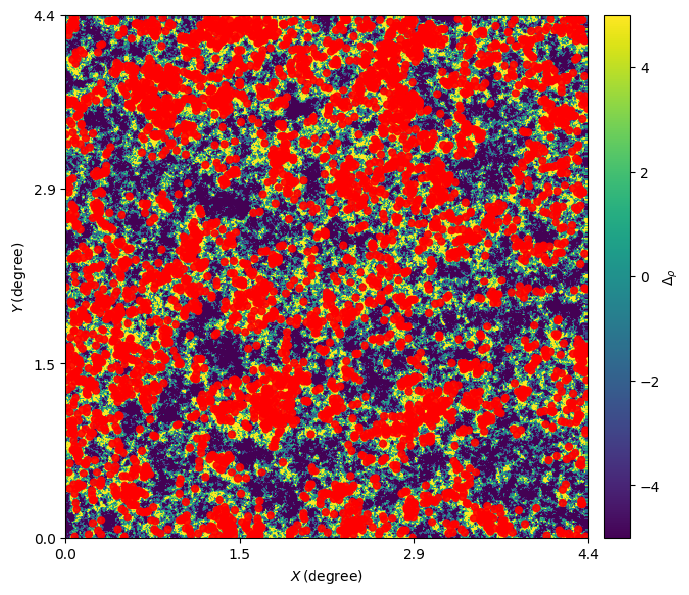

In [18]:
"""
plot_slice module can make slice plots for density.

This function takes few inputs as described below. 

Set "True" for any of these arguments at a time: density_plot,
           halo_overplot, and plot_lines.
"""

boxsize=80  # Size of the box in comoving Mpc (cMpc)
ngrid= 512  # number of grids along the box axis
nproj=10    # no of cells to project
halo_redshift=7.6 # redshift of halos, (Note: at this point it is not used in the function)


#It can read halos and density only from the redshift information but now, lets just do it for one redshift 
# by manually providng the files

#location of density file
root="/Users/anirbanroy/Documents/Limpy/data/density_halos/"

dens_file=root+'updated_smoothed_deltax_z00%1.2f_%d_%dMpc' %(halo_redshift, ngrid,boxsize)

#location of halo catalogue file

halocat_file=root+'halos_z%1.2f_%d_%dMpc' %(halo_redshift, ngrid,boxsize)

'''
#plot only the density slice
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=8, density_plot=True,
           halo_overplot=False ,plot_lines=False,  tick_label='degree')
'''

# overplot halos on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=8, density_plot=False,
           halo_overplot=True ,plot_lines=False, tick_label='degree')

plt.savefig("dens_halos_L80N512_z4.4_log_mmin8.png")

('Minimum halo mass:', 336666900.0)
('Maximum halo mass:', 321717300000.0)


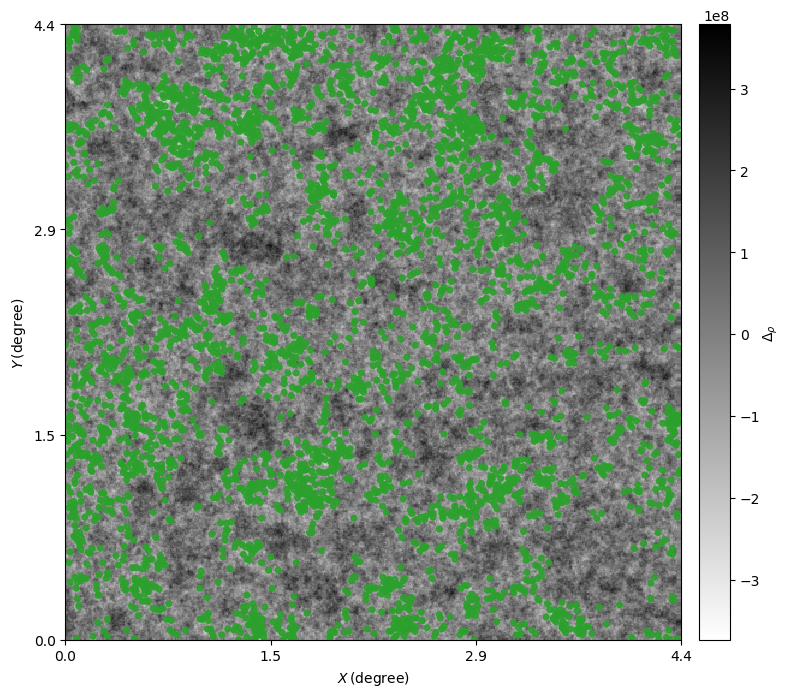

In [12]:
# overplot halos on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=8, density_plot=False,
           halo_overplot=True ,plot_lines=False, tick_label='degree')

('Minimum halo mass:', 336666900.0)
('Maximum halo mass:', 7471935000000.0)


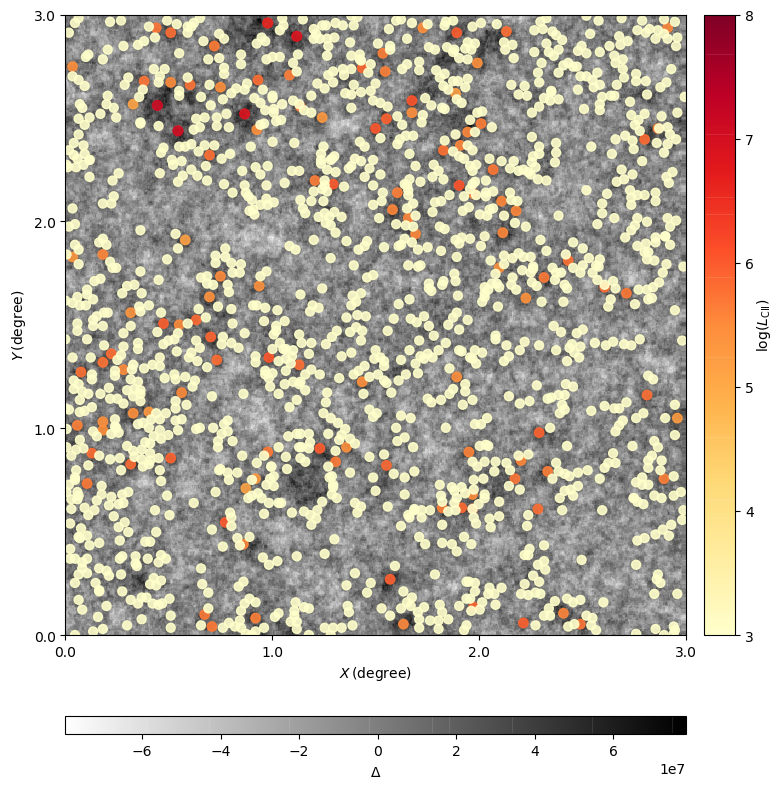

In [19]:
# Overplot CII line luminosities on the density distribution using SFR-CII scatter relation
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=10, use_scatter=True, density_plot=False,
           halo_overplot=False ,plot_lines=True, tick_label='degree')

('Minimum halo mass:', 336666900.0)
('Maximum halo mass:', 7471935000000.0)


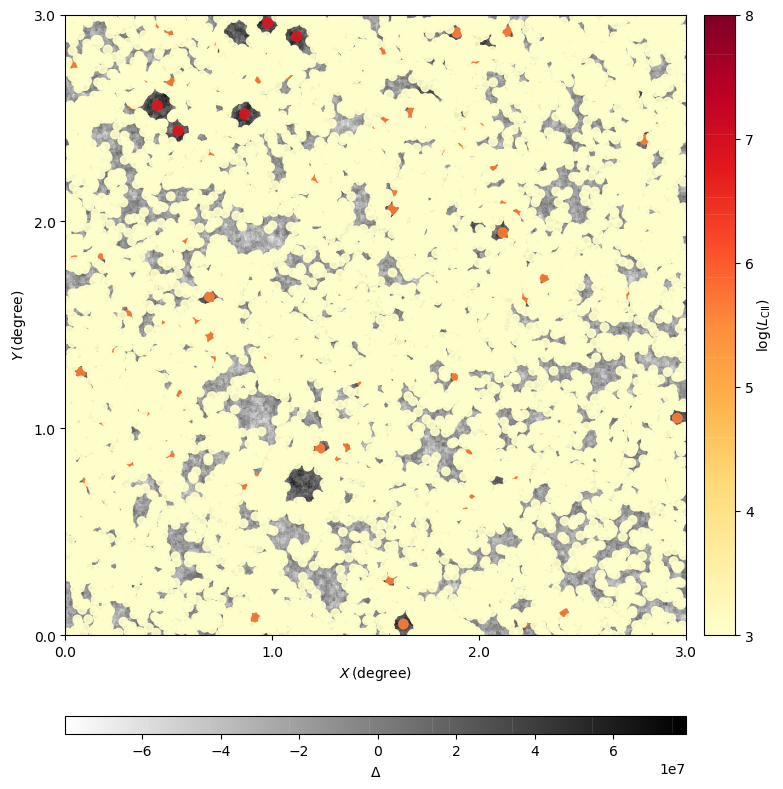

In [20]:
# Overplot CII line luminosities on the density distribution using SFR-CII NON-scatter relation
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=9, use_scatter=False, density_plot=False,
           halo_overplot=False ,plot_lines=True, tick_label='degree')